In [3]:
import pandas as pd
import numpy as np

results_path = 'outputs/ggs/results/NegativeBinomialPiecewise_13f6c147_20260507_2337.csv'
df_results = pd.read_csv(results_path)

total = len(df_results)
exitosas = df_results['mean_S_score'].notna().sum()
fallidas = df_results['mean_S_score'].isna().sum()

print(f"Total configuraciones: {total}")
print(f"Exitosas:              {exitosas}")
print(f"Fallidas (NaN):        {fallidas}")

Total configuraciones: 6912
Exitosas:              6912
Fallidas (NaN):        0


In [2]:
cols_display = [
    'feature_set', 'window_size', 'n_components', 'clipping_threshold',
    'alpha', 'alpha_reg', 'l1_ratio',
    'mean_S_score', 'mean_MAE', 'mean_RMSE', 'mean_C_index',
]

df_top = (
    df_results
    .dropna(subset=['mean_S_score'])
    .sort_values('mean_S_score', ascending=True)
    .head(10)
    .reset_index(drop=True)
)

df_top[cols_display]

,feature_set,window_size,n_components,clipping_threshold,alpha,alpha_reg,l1_ratio,mean_S_score,mean_MAE,mean_RMSE,mean_C_index
0,B,30,20,115,0.1,0.0,1.0,2.447365,10.386102,13.364027,0.907819
1,B,30,20,115,0.1,0.0,0.0,2.447365,10.386102,13.364027,0.907819
2,B,30,20,115,0.1,0.0,0.5,2.447365,10.386102,13.364027,0.907819
3,B,30,15,115,0.1,0.0,0.5,2.454957,10.403037,13.387680,0.907667
4,B,30,15,115,0.1,0.0,1.0,2.454957,10.403037,13.387680,0.907667
5,B,30,15,115,0.1,0.0,0.0,2.454957,10.403037,13.387680,0.907667
6,B,30,10,115,0.1,0.0,0.5,2.464231,10.415936,13.415371,0.907645
7,B,30,10,115,0.1,0.0,0.0,2.464231,10.415936,13.415371,0.907645
8,B,30,10,115,0.1,0.0,1.0,2.464231,10.415936,13.415371,0.907645
9,D,30,10,115,0.1,0.0,0.5,2.465530,10.514475,13.418269,0.903689


In [3]:
from src.models.negative_binomial import NegativeBinomialPiecewise
from src.utils.production_predictor import RULProductionPredictor

best_params = {
    'feature_set':        'B',
    'window_size':        30,
    'n_components':       20,
    'clipping_threshold': 115,
    'link_type':          'log',
    'alpha':              0.1,
    'alpha_reg':          0.0,
    'l1_ratio':           0.0,
}

predictor = RULProductionPredictor.from_config(
    model_class=NegativeBinomialPiecewise,
    params=best_params,
)

print(f"model_name_:        {predictor.model_name_}")
print(f"feature_set:        {predictor.feature_set}")
print(f"window_size:        {predictor.window_size}")
print(f"n_components:       {predictor.n_components}")
print(f"clipping_threshold: {predictor.clipping_threshold}")
print(f"pipeline fitted:    {predictor.pipeline_.is_fitted_}")
print(f"model fitted:       {getattr(predictor.model_, 'is_fitted_', False)}")

Training engines: 140
Test engines: 60
model_name_:        NegativeBinomialPiecewise
feature_set:        B
window_size:        30
n_components:       20
clipping_threshold: 115
pipeline fitted:    True
model fitted:       True


In [5]:
best_metrics = df_top.iloc[0][['mean_S_score', 'mean_C_index', 'mean_MAE', 'mean_RMSE']].to_dict()

session = predictor.save()

print(f"\nstem:     {session.stem}")
print(f"modelo:   {session.path_model}")
print(f"metadata: {session.path_metadata}")

  ✅ Predictor saved: NegativeBinomialPiecewise_B_30w_20pc_20260509_1811.pkl
  📄 Metadata saved: NegativeBinomialPiecewise_B_30w_20pc_20260509_1811.json

stem:     NegativeBinomialPiecewise_B_30w_20pc_20260509_1811
modelo:   outputs/production/models/NegativeBinomialPiecewise_B_30w_20pc_20260509_1811.pkl
metadata: outputs/production/metadata/NegativeBinomialPiecewise_B_30w_20pc_20260509_1811.json


In [9]:
from src.dataset_manager import DatasetManager

# Cargar un motor de test — usamos el primero disponible
_, m_test = DatasetManager.split_dataset()
motor_test_id = m_test[0]

df_test_motor = pd.read_csv(f'data/clean/data_motor_{motor_test_id}.csv')
df_test_motor.insert(0, 'unit_number', motor_test_id)
X_test_motor = df_test_motor.drop(columns=['RUL'])

print(f"Motor de test: {motor_test_id}")
print(f"Ciclos disponibles: {len(X_test_motor)}")
print(f"RUL real último ciclo: {df_test_motor['RUL'].iloc[-1]:.1f}")

# Predicción — último ciclo
rul_pred = predictor.predict(X_test_motor, return_mode='last')
print(f"\nRUL predicho: {rul_pred[0]:.1f} ciclos")

# Trayectoria completa
rul_traj = predictor.predict(X_test_motor, return_mode='all')
print(f"Trayectoria: {len(rul_traj)} ventanas, rango [{rul_traj.min():.1f}, {rul_traj.max():.1f}]")

Training engines: 140
Test engines: 60
Motor de test: 96
Ciclos disponibles: 336
RUL real último ciclo: 0.0

RUL predicho: 15.2 ciclos
Trayectoria: 307 ventanas, rango [14.8, 115.0]


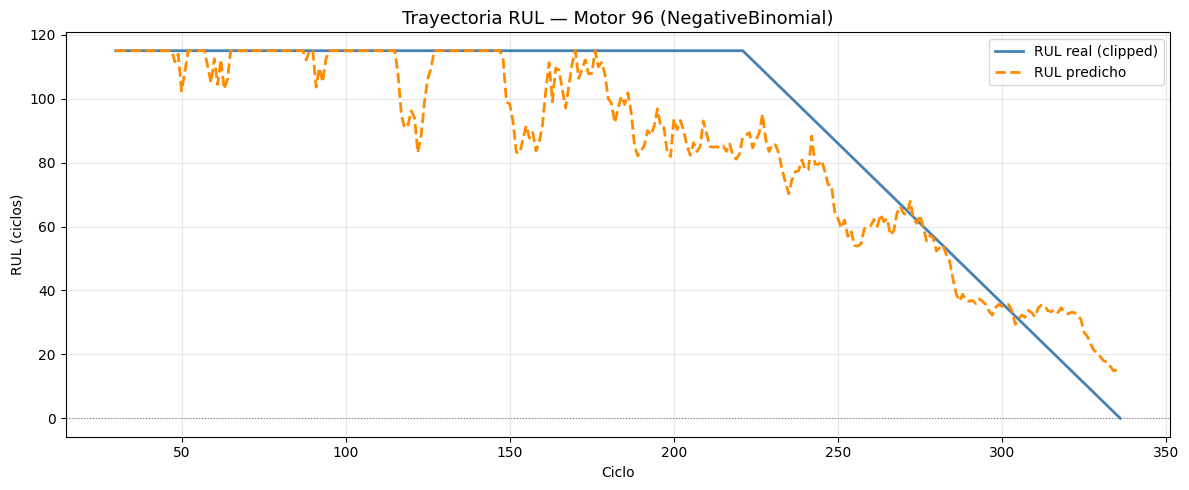

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Ciclos correspondientes a cada ventana (t_stop)
_, _, t_stop_test, _, _ = predictor.pipeline_.transform(X_test_motor)

# RUL real clippeado al mismo threshold que el modelo
rul_real = df_test_motor['RUL'].values[predictor.window_size - 1:]
rul_real_clipped = np.minimum(rul_real, predictor.clipping_threshold)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(t_stop_test, rul_real_clipped, label='RUL real (clipped)', color='steelblue',  linewidth=2)
ax.plot(t_stop_test, rul_traj,         label='RUL predicho',       color='darkorange', linewidth=2, linestyle='--')
ax.axhline(y=0, color='gray', linewidth=0.8, linestyle=':')

ax.set_title(f'Trayectoria RUL — Motor {motor_test_id} (NegativeBinomial)', fontsize=13)
ax.set_xlabel('Ciclo')
ax.set_ylabel('RUL (ciclos)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Vida total de cada motor de test = max ciclos observados
vida_test = []
for idx in m_test:
    df = pd.read_csv(f'data/clean/data_motor_{idx}.csv')
    vida_test.append({'motor_id': idx, 'ciclos': len(df)})

df_vida = pd.DataFrame(vida_test).sort_values('ciclos').reset_index(drop=True)

print(f"Vida mínima:  {df_vida['ciclos'].min()} ciclos — Motor {df_vida.iloc[0]['motor_id']:.0f}")
print(f"Vida máxima:  {df_vida['ciclos'].max()} ciclos — Motor {df_vida.iloc[-1]['motor_id']:.0f}")
print(f"Vida mediana: {df_vida['ciclos'].median():.0f} ciclos")
print()

# Seleccionar tres representativos
motor_corto  = int(df_vida.iloc[0]['motor_id'])
motor_medio  = int(df_vida.iloc[len(df_vida)//2]['motor_id'])
motor_largo  = int(df_vida.iloc[-1]['motor_id'])

print(f"Motor corto:  {motor_corto}  — {df_vida.iloc[0]['ciclos']} ciclos")
print(f"Motor medio:  {motor_medio}  — {df_vida.iloc[len(df_vida)//2]['ciclos']} ciclos")
print(f"Motor largo:  {motor_largo}  — {df_vida.iloc[-1]['ciclos']} ciclos")

Vida mínima:  48 ciclos — Motor 125
Vida máxima:  362 ciclos — Motor 69
Vida mediana: 156 ciclos

Motor corto:  125  — 48 ciclos
Motor medio:  19  — 158 ciclos
Motor largo:  69  — 362 ciclos


In [15]:
vida_test = []
for idx in m_test:
    df = pd.read_csv(f'data/clean/data_motor_{idx}.csv')
    vida_test.append({
        'motor_id':    idx,
        'ciclos':      len(df),
        'rul_inicial': df['RUL'].iloc[0],
        'rul_final':   df['RUL'].iloc[-1],
    })

df_vida = pd.DataFrame(vida_test).sort_values('rul_inicial').reset_index(drop=True)

# Seleccionar tres representativos por RUL inicial
motor_corto  = int(df_vida.iloc[0]['motor_id'])
motor_medio  = int(df_vida.iloc[len(df_vida)//2]['motor_id'])
motor_largo  = int(df_vida.iloc[-1]['motor_id'])

print(f"Motor vida corta:  {motor_corto}  — RUL inicial={df_vida.iloc[0]['rul_inicial']:.0f},  ciclos observados={df_vida.iloc[0]['ciclos']:.0f}")
print(f"Motor vida media:  {motor_medio}  — RUL inicial={df_vida.iloc[len(df_vida)//2]['rul_inicial']:.0f}, ciclos observados={df_vida.iloc[len(df_vida)//2]['ciclos']:.0f}")
print(f"Motor vida larga:  {motor_largo}  — RUL inicial={df_vida.iloc[-1]['rul_inicial']:.0f}, ciclos observados={df_vida.iloc[-1]['ciclos']:.0f}")

Motor vida corta:  39  — RUL inicial=127,  ciclos observados=128
Motor vida media:  79  — RUL inicial=198, ciclos observados=199
Motor vida larga:  69  — RUL inicial=361, ciclos observados=362


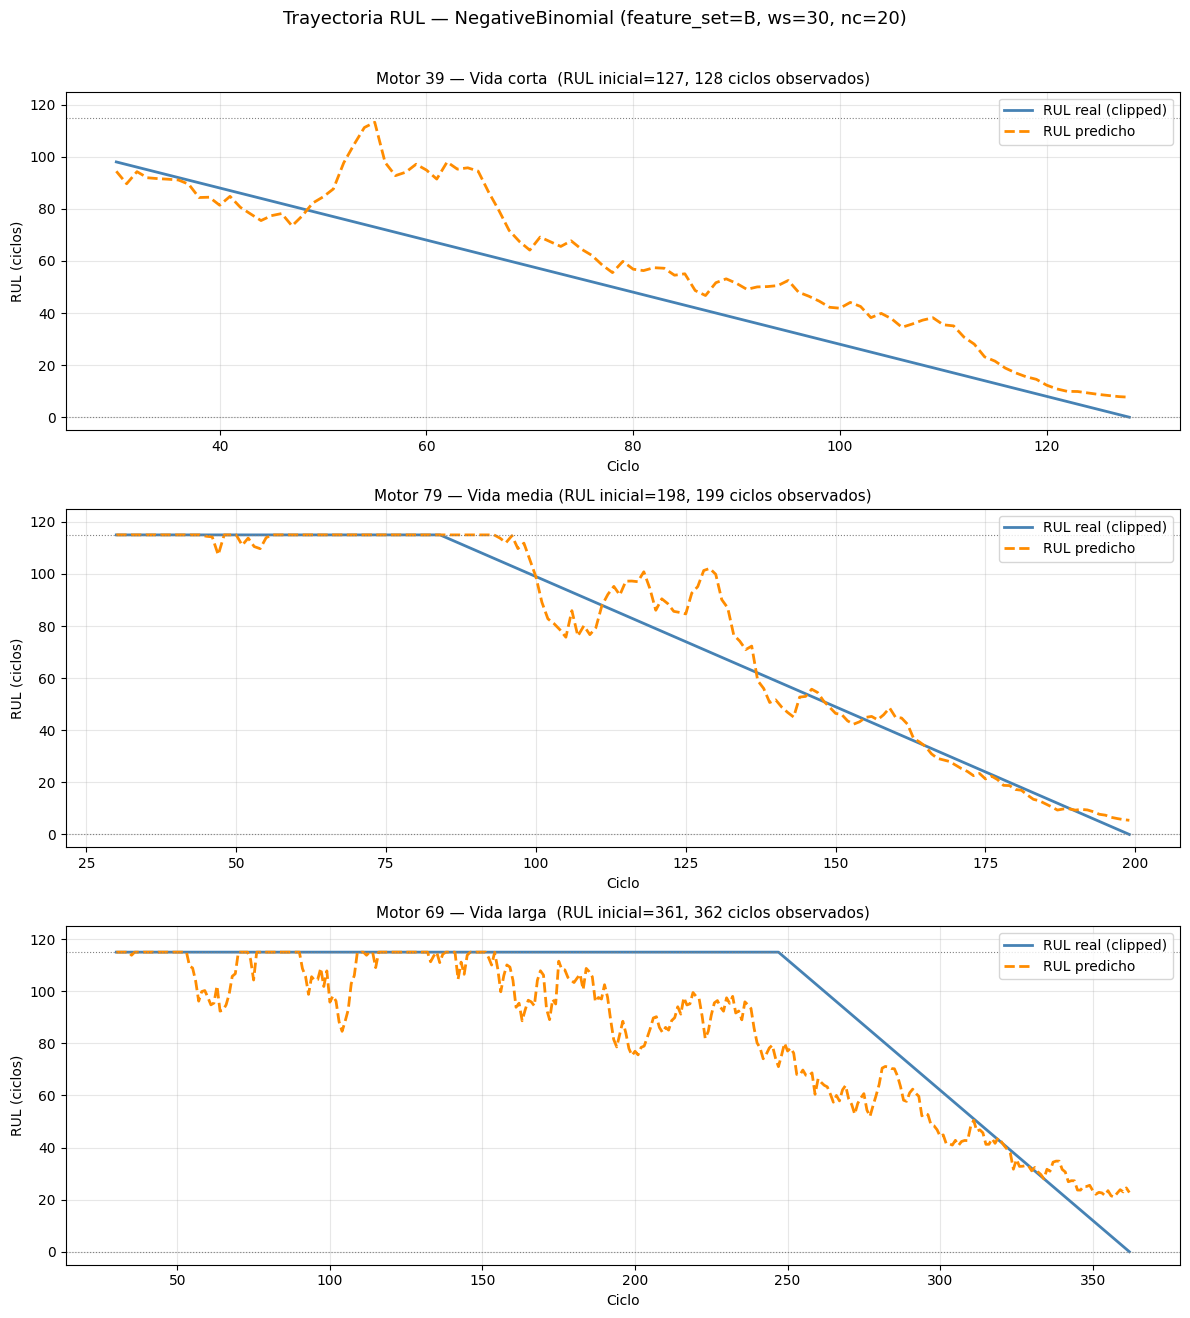

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 13))

motores = [
    (motor_corto, 'Vida corta  (RUL inicial=127, 128 ciclos observados)'),
    (motor_medio, 'Vida media (RUL inicial=198, 199 ciclos observados)'),
    (motor_largo, 'Vida larga  (RUL inicial=361, 362 ciclos observados)'),
]

for ax, (motor_id, titulo) in zip(axes, motores):
    df_m = pd.read_csv(f'data/clean/data_motor_{motor_id}.csv')
    df_m.insert(0, 'unit_number', motor_id)
    X_m = df_m.drop(columns=['RUL'])

    _, _, t_stop_m, _, _ = predictor.pipeline_.transform(X_m)
    rul_pred_m = predictor.predict(X_m, return_mode='all')

    rul_real_m = np.minimum(
        df_m['RUL'].values[predictor.window_size - 1:],
        predictor.clipping_threshold,
    )

    ax.plot(t_stop_m, rul_real_m, label='RUL real (clipped)', color='steelblue',  linewidth=2)
    ax.plot(t_stop_m, rul_pred_m, label='RUL predicho',       color='darkorange', linewidth=2, linestyle='--')
    ax.axhline(y=0, color='gray', linewidth=0.8, linestyle=':')
    ax.axhline(y=predictor.clipping_threshold, color='gray', linewidth=0.8, linestyle=':')

    ax.set_title(f'Motor {motor_id} — {titulo}', fontsize=11)
    ax.set_xlabel('Ciclo')
    ax.set_ylabel('RUL (ciclos)')
    ax.set_ylim(-5, predictor.clipping_threshold + 10)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Trayectoria RUL — NegativeBinomial (feature_set=B, ws=30, nc=20)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [4]:
# Verificar duplicados en el checkpoint del RF
df = pd.read_csv('outputs/ggs/results/NegativeBinomialPiecewise_13f6c147_20260507_2337.csv')

cols_params = [
    'feature_set', 'window_size', 'n_components', 'clipping_threshold',
    'alpha', 'alpha_reg', 'l1_ratio',
    'mean_S_score', 'mean_MAE', 'mean_RMSE', 'mean_C_index',
]

n_duplicados = df.duplicated(subset=cols_params).sum()
print(f"Filas totales:  {len(df)}")
print(f"Duplicados:     {n_duplicados}")
print(f"Únicas:         {len(df) - n_duplicados}")

Filas totales:  6912
Duplicados:     0
Únicas:         6912
